# **MÓDULO 39 - Exercicio - Aplicando XGboost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [1]:
# Impotação para arquivo

import os

# Importação para dados

import pandas as pd
import numpy as np

# Importação para Gráficos

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Importação para pre processamento

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# importação para ML

import xgboost as xgb

# Importação para métricas de resultados

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


- Carregando base de dados

In [2]:
# Definindo caminho do arquivo

path = '.\\CARRO_CLIENTES.csv'

# Verificando se o caminho existe

if os.path.exists(path):
    print("Caminho encontrado")

else:
    print("Caminho não foi encontrado")

# Definindo base de dados
    

df = pd.read_csv(path)  

df


Caminho encontrado


,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0
...,...,...,...,...,...
995,863,Male,38,59000,0
996,800,Female,47,23500,0
997,407,Female,28,138500,1
998,299,Female,48,134000,1


- Verificando a base

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


- Remoção da coluna ID

In [4]:
# Removendo coluna ID

df = df.drop(columns= "User ID")

# Verificando se a coluna foi removida

df

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0
...,...,...,...,...
995,Male,38,59000,0
996,Female,47,23500,0
997,Female,28,138500,1
998,Female,48,134000,1


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

- Codificação coluna Gender

In [5]:
# Instanciando Label Encoder para codificar a coluna

labelE = LabelEncoder()

# Codificando a coluna Gender

try:
    df["Gender_Encoded"] = labelE.fit_transform(df['Gender'])
    print("Coluna decodificada! ")

except:
    print("Coluna não decodificada")    

# Verificando resultado

df

Coluna decodificada! 


,Gender,Age,AnnualSalary,Purchased,Gender_Encoded
0,Male,35,20000,0,1
1,Male,40,43500,0,1
2,Male,49,74000,0,1
3,Male,40,107500,1,1
4,Male,25,79000,0,1
...,...,...,...,...,...
995,Male,38,59000,0,1
996,Female,47,23500,0,0
997,Female,28,138500,1,0
998,Female,48,134000,1,0


Obs: Após a codificação ficou Male = 1 e Female = 0

- Exclusão da coluna objeto

In [6]:
# Excluindo coluna Gender

df = df.drop(columns="Gender")

# Verificando resultado

df

,Age,AnnualSalary,Purchased,Gender_Encoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1
...,...,...,...,...
995,38,59000,0,1
996,47,23500,0,0
997,28,138500,1,0
998,48,134000,1,0


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

- Matriz de correlação

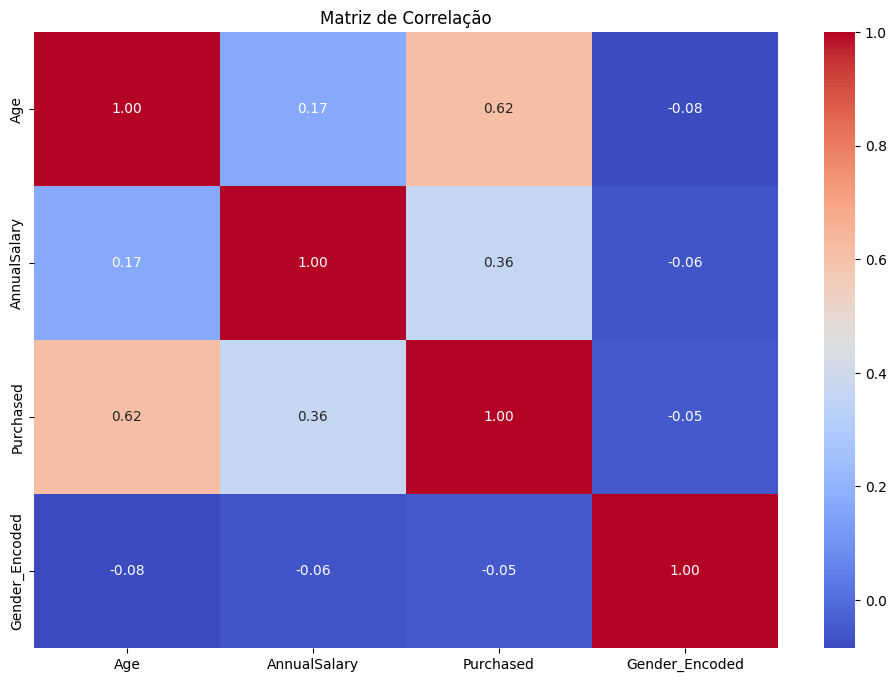

In [7]:
# Defininfo a correlação

matriz_corr = df.select_dtypes(include="number").corr()

# Criando o gráfico

plt.figure(figsize=(12,8))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size":10})
plt.title("Matriz de Correlação")
plt.show()

Obs: Visando realizar uma breve análise irei fazer dois gráficos para entender melhor como a variável target se relaciona com as outras duas variáveis que mais se correlacionam com ela.

- Age x Purchased

In [8]:
fig = px.box(
    df,
    x="Purchased",
    y="Age",
    color="Purchased",
    labels={"Purchased": "Comprou o carro", "Age": "Idade"}
)
fig.update_xaxes(tickvals=[0, 1], ticktext=["Não comprou", "Comprou"])
fig.update_layout(title="Idade por decisão de compra")
fig.show()

Obs: O gráfico mostra uma separação bastante clara entre os dois grupos: clientes que não compraram o carro têm idade mediana em torno de 35 anos, enquanto os que compraram têm mediana em torno de 50 anos, com pouca sobreposição entre as distribuições. Isso é consistente com a correlação de 0.62 observada na matriz — a mais alta entre as variáveis e o target — e sugere que a idade é um forte indicador da propensão à compra.

- Annual Salary x Purchased

In [9]:
# Criando gráfico

fig = px.box(
    df,
    x="Purchased",
    y="AnnualSalary",
    color="Purchased",
    labels={"Purchased": "Comprou o carro", "AnnualSalary": "Salário anual"}
)
fig.update_xaxes(tickvals=[0, 1], ticktext=["Não comprou", "Comprou"])
fig.update_layout(title="Salário anual por decisão de compra")
fig.show()

Obs: O gráfico mostra que clientes com salário anual maior têm maior propensão a comprar o carro — a mediana de quem não comprou é de aproximadamente R$ 60k, enquanto a de quem comprou é de quase R$ 100k. Esse resultado é coerente com a correlação de 0.36 observada na matriz e faz sentido no contexto: um carro representa um investimento considerável, e maior renda facilita essa decisão. Vale notar que renda baixa não impede a compra — há clientes com salários menores presentes em ambos os grupos —, mas a tendência geral é clara: quanto maior a renda, maior a chance de compra.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

- Separação em X e y

In [10]:
# Separando em X e y

X = df.drop(columns="Purchased")
y = df["Purchased"]


- Separação em treino e teste

In [11]:
# Sepando em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=48)


# Verificando Resultado

print("O tamanho de X_train é ", X_train.shape)
print("O tamanho de y_train é ", y_train.shape)
print("O tamanho de X_test é ", X_test.shape)
print("O tamanho de y_test é ", y_test.shape)

O tamanho de X_train é  (800, 3)
O tamanho de y_train é  (800,)
O tamanho de X_test é  (200, 3)
O tamanho de y_test é  (200,)


# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

- Criando modelo

In [12]:
# Instanciando modelo

model_xgboost = xgb.XGBClassifier(
    n_estimators= 400, # Número de árvores feitas
    learning_rate=0.1, # Quanto de correção do erro da árvore anterior é aplicada
    subsample = 0.95, # Quanto porcento (aleatoriamente) dos dados é fornecido para cada árvores
    max_depth = 4, # Profundidade máxima da árvore
    random_state=48
)

- Treinando modelo

In [13]:
# Treinando o modelo

model_xgboost.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

- Realizando previsões

In [14]:
# Realizando previsões

y_pred = model_xgboost.predict(X_test)
y_pred_prob = model_xgboost.predict_proba(X_test)

# Verificando probabilidades

print(y_pred_prob)

[[1.08108521e-02 9.89189148e-01]
 [3.20976973e-03 9.96790230e-01]
 [8.03741693e-01 1.96258277e-01]
 [9.94977534e-01 5.02246013e-03]
 [9.99277771e-01 7.22248340e-04]
 [9.99981105e-01 1.88902395e-05]
 [7.70434856e-01 2.29565144e-01]
 [9.92296815e-01 7.70316320e-03]
 [2.76210904e-02 9.72378910e-01]
 [9.99671519e-01 3.28453956e-04]
 [9.98930931e-01 1.06907950e-03]
 [9.99894857e-01 1.05140927e-04]
 [9.99883831e-01 1.16192583e-04]
 [2.61721015e-02 9.73827899e-01]
 [8.11874390e-01 1.88125625e-01]
 [9.96530592e-01 3.46943410e-03]
 [1.08122826e-04 9.99891877e-01]
 [9.99964714e-01 3.53105606e-05]
 [9.99172926e-01 8.27096985e-04]
 [5.14751196e-01 4.85248774e-01]
 [1.06905699e-01 8.93094301e-01]
 [3.33410501e-03 9.96665895e-01]
 [9.99784589e-01 2.15400578e-04]
 [8.01640630e-01 1.98359385e-01]
 [9.99616683e-01 3.83290695e-04]
 [3.79461050e-03 9.96205389e-01]
 [9.99821723e-01 1.78299684e-04]
 [9.99358773e-01 6.41227525e-04]
 [2.76088715e-02 9.72391129e-01]
 [8.48771930e-02 9.15122807e-01]
 [9.999055

# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

- Tranformação das probabilidades

In [15]:
# Tranformando para inteiro as probabilidades depende se passou ou não na condição

y_pred_manual = (y_pred_prob[:, 1] >= 0.5).astype(int)

- Avaliando desempenho

In [16]:
# Avaliando métricas de desempenho

cr = classification_report(y_test, y_pred_manual)
conf_matriz = confusion_matrix(y_test, y_pred_manual)

print(cr)
print(conf_matriz)

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       109
           1       0.87      0.87      0.87        91

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200

[[97 12]
 [12 79]]


Obs: O modelo apresentou um desempenho muito bom, com acurácia de 88%. Ele teve uma leve facilidade maior em identificar quem não compraria o carro (recall de 0.89) em comparação a quem compraria (recall de 0.87) — não é o cenário ideal, já que normalmente é mais valioso identificar corretamente os compradores, mas a diferença é pequena e o resultado geral continua sólido.
Considerando que o modelo trabalhou com apenas 3 variáveis, esse resultado é bastante positivo. A limitação de max_depth=4 parece ter ajudado o modelo a generalizar bem, sem se aprofundar demais em padrões específicos do conjunto de treino — ou seja, sem overfitting. No geral, o modelo demonstrou boa capacidade de identificar a propensão de compra dos clientes, com espaço para melhorias futuras (mais variáveis, ajuste fino de hiperparâmetros).

# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

- Lista das features importance

In [17]:
# Verificando importancia

importances = model_xgboost.get_booster().get_score(importance_type='gain')

# Convertendo o dicionário de importâncias para um DataFrame
importance_df = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'].astype(float)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

          Feature  Importance
0             Age    1.996987
1    AnnualSalary    1.295943
2  Gender_Encoded    0.447202


Obs: Sim, as features mais importantes para o modelo coincidem exatamente com as que apresentaram maior correlação com a variável target: Age (2.02), AnnualSalary (1.26) e Gender_Encoded (0.41), na mesma ordem da matriz de correlação (0.62, 0.36 e -0.05, respectivamente). Em datasets com mais variáveis e correlações mais próximas entre si, é possível que essa ordem se altere, já que a feature importance do XGBoost também capta interações entre variáveis que a correlação simples não consegue medir.